Dataset Shape : (569, 30)
Target Shape : (569,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.8022 - loss: 0.5304 - val_accuracy: 0.9011 - val_loss: 0.3381
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9478 - loss: 0.2565 - val_accuracy: 0.9341 - val_loss: 0.1738
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9698 - loss: 0.1273 - val_accuracy: 0.9670 - val_loss: 0.1120
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9808 - loss: 0.0767 - val_accuracy: 0.9780 - val_loss: 0.0923
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9835 - loss: 0.0569 - val_accuracy: 0.9780 - val_loss: 0.0864
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9890 - loss: 0.0472 - val_accuracy: 0.9670 - val_loss: 0.0827
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9863 - loss: 0.0408 - val_accuracy: 0.9670 - val_loss: 0.0837
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9890 - loss: 0.0334 - val_accuracy: 0.9670 - v

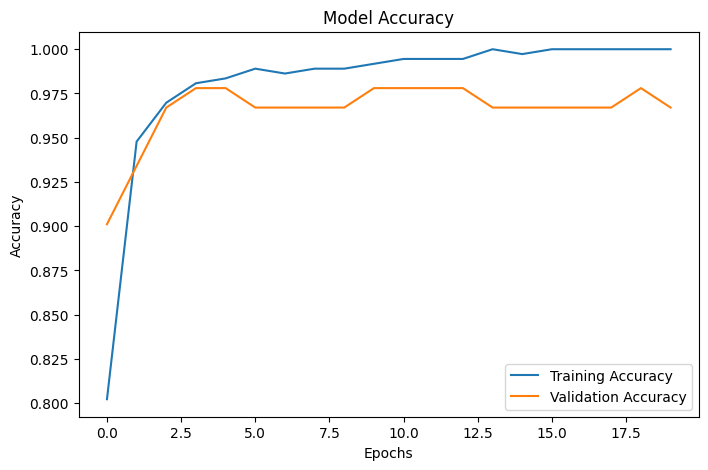

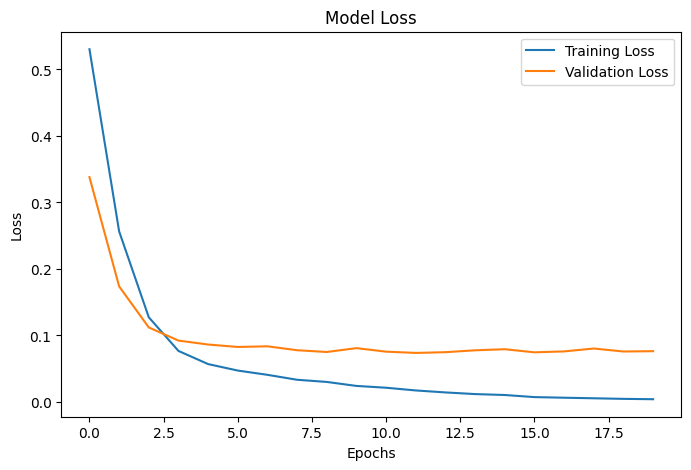

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

Predictions :
[[9.8838902e-01]
 [1.2606624e-06]
 [2.0731422e-04]
 [9.9997079e-01]
 [9.9999791e-01]]


In [1]:
# Experiment No. 2
# Title: Backpropagation using TensorFlow and Keras

# Aim:
# To implement Backpropagation Algorithm using TensorFlow and Keras
# for binary classification on the Breast Cancer dataset.

# Import Required Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input

# Load Breast Cancer Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape :", X.shape)
print("Target Shape :", y.shape)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Neural Network Model
model = Sequential([

    Input(shape=(30,)),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Plot Training Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()

# Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

# Predict Sample
prediction = model.predict(X_test[:5])

print("\nPredictions :")
print(prediction)

# Conclusion
# Successfully implemented Backpropagation using TensorFlow and Keras
# for binary classification on Breast Cancer dataset.